# **HW11: Clustering and Anomaly Detection**

#### **Attention:** *This assignment is to be completed individually. Group work is not permitted.*

# **Introduction to Clustering and Anomaly Detection**

In this notebook exercise, we will explore **unsupervised learning** techniques for discovering patterns in data without labeled examples. We'll focus on two fundamental clustering algorithms and their application to anomaly detection.

## **What is Clustering?**

Clustering is an unsupervised learning technique that groups similar data points together based on their features. Unlike supervised learning, clustering algorithms discover structure in data without predefined labels.

## **K-Means Clustering**

K-Means is a centroid-based clustering algorithm that:
- Partitions data into **k** clusters
- Assigns each point to the cluster with the nearest **centroid** (center point)
- Iteratively updates centroids until convergence

**Algorithm Steps:**
1. Initialize k centroids randomly
2. Assign each point to the nearest centroid
3. Update centroids as the mean of assigned points
4. Repeat steps 2-3 until convergence

## **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**

DBSCAN is a density-based clustering algorithm that:
- Groups points that are closely packed together
- Marks points in low-density regions as **outliers (noise)**
- Does **not** require specifying the number of clusters in advance

**Key Parameters:**
- **eps (ε)**: Maximum distance between two points to be considered neighbors
- **min_samples**: Minimum points required to form a dense region (core point)

## **Anomaly Detection**

Anomaly detection identifies data points that differ significantly from the majority. Clustering can be used for anomaly detection by:
- Identifying points far from cluster centroids (K-Means)
- Identifying noise points that don't belong to any cluster (DBSCAN)

## **Objectives**

In this exercise, you will:
1. Generate synthetic datasets for clustering experiments
2. Implement K-Means clustering from scratch
3. Apply DBSCAN clustering using scikit-learn
4. Compare K-Means and DBSCAN on different data distributions
5. Use clustering for anomaly detection
6. Understand when to use each algorithm

## **Import Libraries**

Let's start by importing the necessary libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


---
# **Part 1: K-Means Clustering from Scratch**
---

## **Generate Synthetic Data**

Create a synthetic dataset with three distinct clusters using the `make_blobs` function from scikit-learn.

**Requirements:**
- Generate **300 samples** total
- Create **3 cluster centers**
- Use **cluster_std=1.0** for the standard deviation
- Use **random_state=42** for reproducibility


In [2]:
# Generate synthetic data with 3 clusters
X, true_labels = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFirst 5 data points:")
for i in range(5):
    print(f"  Point {i}: [{X[i, 0]:.2f}, {X[i, 1]:.2f}]")

Dataset shape: (300, 2)
Number of samples: 300
Number of features: 2

First 5 data points:
  Point 0: [-7.34, -7.73]
  Point 1: [-7.74, -7.26]
  Point 2: [-1.69, 7.79]
  Point 3: [4.42, 3.07]
  Point 4: [-8.92, -7.89]


## **TASK 1: Visualize the Data**

Create a scatter plot to visualize the generated data. At this point, we're treating this as an unsupervised problem, so plot all points in the same color.

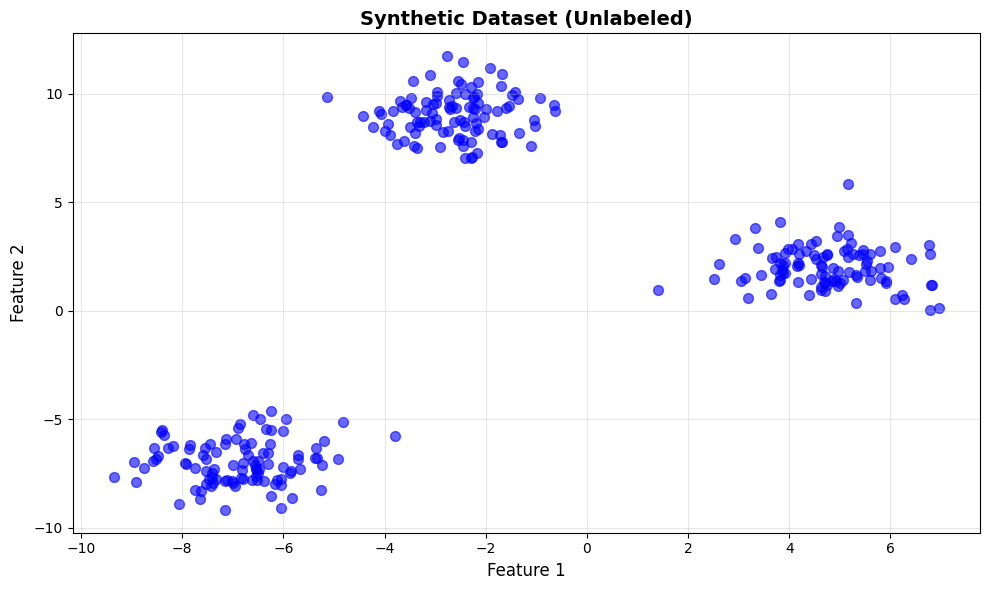

The data appears to have natural groupings, but we don't know the labels.
K-Means will try to discover these clusters automatically.


In [ ]:
# Write your code here

...

## **TASK 2: Initialize Centroids**

Implement a function to randomly initialize k centroids by selecting k random data points from the dataset.

**Instructions:**
- Randomly select k data points from the dataset as initial centroids
- Use `np.random.permutation()` to shuffle indices and select the first k
- Return the centroids as a NumPy array

In [3]:
def initialize_centroids(data, k):
    """
    Randomly initialize k centroids from the dataset.
    
    Parameters:
    -----------
    data : numpy array
        The dataset (n_samples, n_features)
    k : int
        Number of clusters
    
    Returns:
    --------
    centroids : numpy array
        Initial centroids (k, n_features)
    """
    # Write your code here
    indices = np.random.permutation(data.shape[0])
    centroids = data[indices[:k]]
    
    return centroids

# Test the function
test_centroids = initialize_centroids(X, 3)
print(f"Initialized {len(test_centroids)} centroids:")
for i, c in enumerate(test_centroids):
    print(f"  Centroid {i}: [{c[0]:.2f}, {c[1]:.2f}]")

Initialized 3 centroids:
  Centroid 0: [4.05, 2.82]
  Centroid 1: [-6.76, -6.37]
  Centroid 2: [4.92, 1.35]


## **TASK 3: Assign Points to Clusters**

Implement a function that assigns each data point to the nearest centroid based on Euclidean distance.

**Instructions:**
- For each data point, calculate the Euclidean distance to each centroid
- Assign the point to the cluster with the minimum distance
- Return an array of cluster assignments

**Euclidean Distance Formula:**
$$d(p, c) = \sqrt{\sum_{i=1}^{n}(p_i - c_i)^2}$$

In [4]:
def assign_clusters(data, centroids):
    """
    Assign each data point to the nearest centroid.
    
    Parameters:
    -----------
    data : numpy array
        The dataset (n_samples, n_features)
    centroids : numpy array
        Current centroids (k, n_features)
    
    Returns:
    --------
    assignments : numpy array
        Cluster assignment for each point (n_samples,)
    """
    # Write your code here
    
    assignments = []
    for point in data:
        # Calculate Euclidean distance to each centroid
        distances = [np.linalg.norm(point - c) for c in centroids]
        nearest = np.argmin(distances)
        assignments.append(nearest)
    
    return np.array(assignments)

# Test the function
test_assignments = assign_clusters(X, test_centroids)
print(f"Cluster assignments shape: {test_assignments.shape}")
print(f"Unique clusters: {np.unique(test_assignments)}")
print(f"Points per cluster: {[np.sum(test_assignments == i) for i in range(3)]}")

Cluster assignments shape: (300,)
Unique clusters: [0 1 2]
Points per cluster: [np.int64(145), np.int64(100), np.int64(55)]


## **TASK 4: Update Centroids**

Implement a function that updates each centroid to be the mean of all points assigned to that cluster.

**Instructions:**
- For each cluster, calculate the mean position of all assigned points
- Handle the case where a cluster might have no points assigned
- Return the new centroids as a NumPy array

In [5]:
def update_centroids(data, assignments, k):
    """
    Update centroids based on current cluster assignments.
    
    Parameters:
    -----------
    data : numpy array
        The dataset (n_samples, n_features)
    assignments : numpy array
        Current cluster assignments (n_samples,)
    k : int
        Number of clusters
    
    Returns:
    --------
    centroids : numpy array
        Updated centroids (k, n_features)
    """
    # Write your code here
    
    n_features = data.shape[1]
    centroids = np.zeros((k, n_features))
    
    for i in range(k):
        # Get all points assigned to cluster i
        points_in_cluster = data[assignments == i]
        if len(points_in_cluster) > 0:
            # Update centroid as the mean of assigned points
            centroids[i] = np.mean(points_in_cluster, axis=0)
    
    return centroids

# Test the function
new_centroids = update_centroids(X, test_assignments, 3)
print("Updated centroids:")
for i, c in enumerate(new_centroids):
    print(f"  Centroid {i}: [{c[0]:.2f}, {c[1]:.2f}]")

Updated centroids:
  Centroid 0: [-0.54, 7.04]
  Centroid 1: [-6.88, -6.98]
  Centroid 2: [5.27, 1.53]


## **TASK 5: Compute Inertia (Total Within-Cluster Variance)**

Implement a function to compute the **inertia**, which is the sum of squared distances from each point to its assigned centroid. This metric helps us evaluate how compact our clusters are.

**Formula:**
$$\text{Inertia} = \sum_{i=1}^{n} ||x_i - c_{a_i}||^2$$

Where $x_i$ is data point $i$ and $c_{a_i}$ is the centroid of its assigned cluster.

In [6]:
def compute_inertia(data, centroids, assignments):
    """
    Compute the total within-cluster variance (inertia).
    
    Parameters:
    -----------
    data : numpy array
        The dataset (n_samples, n_features)
    centroids : numpy array
        Current centroids (k, n_features)
    assignments : numpy array
        Cluster assignments (n_samples,)
    
    Returns:
    --------
    inertia : float
        Total within-cluster variance
    """
    # Write your code here
    inertia = 0;
    for i, point in enumerate(data):
        centroid = centroids[assignments[i]]
        inertia += np.sum((point - centroid)**2)
    
    return inertia

# Test the function
test_inertia = compute_inertia(X, new_centroids, test_assignments)
print(f"Inertia: {test_inertia:.2f}")

Inertia: 3203.13


## **TASK 6: Run K-Means Algorithm**

Now combine all the functions to run the complete K-Means algorithm.

**Instructions:**
- Initialize centroids
- Run for a fixed number of iterations (10 iterations)
- In each iteration: assign clusters, then update centroids
- Print the inertia at each iteration to monitor convergence

In [7]:
def kmeans(data, k, n_iterations=10):
    """
    Run the K-Means clustering algorithm.
    
    Parameters:
    -----------
    data : numpy array
        The dataset
    k : int
        Number of clusters
    n_iterations : int
        Number of iterations to run
    
    Returns:
    --------
    centroids : numpy array
        Final centroids
    assignments : numpy array
        Final cluster assignments
    inertia_history : list
        Inertia at each iteration
    """
    # Write your code here
    
    # Initialize centroids
    centroids = initialize_centroids(data, k)
    inertia_history = []
    
    print(f"Running K-Means with k={k} for {n_iterations} iterations...\n")
    
    for i in range(n_iterations):
        # Assign clusters
        assignments = assign_clusters(data, centroids)
        
        # Update centroids
        centroids = update_centroids(data, assignments, k)
        
        # Compute and store inertia
        inertia = compute_inertia(data, centroids, assignments)
        inertia_history.append(inertia)
        
        print(f"Iteration {i+1}: Inertia = {inertia:.2f}")
    
    return centroids, assignments, inertia_history

# Run K-Means
final_centroids, final_assignments, inertia_history = kmeans(X, k=3, n_iterations=10)

Running K-Means with k=3 for 10 iterations...

Iteration 1: Inertia = 3365.82
Iteration 2: Inertia = 566.86
Iteration 3: Inertia = 566.86
Iteration 4: Inertia = 566.86
Iteration 5: Inertia = 566.86
Iteration 6: Inertia = 566.86
Iteration 7: Inertia = 566.86
Iteration 8: Inertia = 566.86
Iteration 9: Inertia = 566.86
Iteration 10: Inertia = 566.86


## **TASK 7: Visualize K-Means Results**

Create a visualization showing:
1. The data points colored by their cluster assignment
2. The final centroids marked with red X markers

C:\Users\cruzj\AppData\Local\Temp\ipykernel_4500\3892563781.py:6: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(final_centroids[:, 0], final_centroids[:, 1],


AttributeError: PathCollection.set() got an unexpected keyword argument 'fontweight'

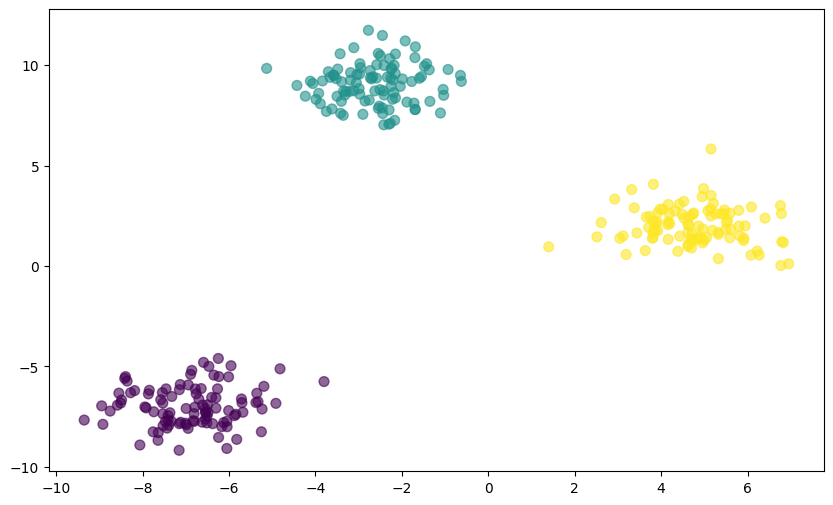

In [10]:
# Write your code here
plt.figure(figsize=(10, 6))

plt.scatter(X[:, 0], X[:, 1], c=final_assignments, cmap='viridis', alpha=0.6, s=50)

plt.scatter(final_centroids[:, 0], final_centroids[:, 1], 
            c='red', marker='x', s=200, fontweight='bold', 
            edgecolors='black', linewidths=3, label='Centroids')

plt.title('K-Means Clustering Results (k=3)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFinal Centroids:")
for i, c in enumerate(final_centroids):
    print(f"  Cluster {i}: [{c[0]:.2f}, {c[1]:.2f}]")

## **TASK 8: QUESTION**

Looking at the inertia values across iterations, what pattern do you observe? Why does this happen?

**YOUR ANSWER:**

The inertia decreases with each iteration and eventually stabilizes (converges). This happens because K-Means is an optimization algorithm that minimizes the within-cluster variance. Each iteration either improves or maintains the current solution, never making it worse. The algorithm converges when the centroids stop moving significantly.

---
# **Part 2: DBSCAN Clustering**
---

## **Generate Non-Spherical Data**

K-Means assumes spherical clusters. Let's create a dataset where clusters have non-spherical shapes using the `make_moons` function.

**Requirements:**
- Generate **300 samples** using `make_moons`
- Use **noise=0.05** for slight variation
- Use **random_state=42** for reproducibility

Moon dataset shape: (300, 2)


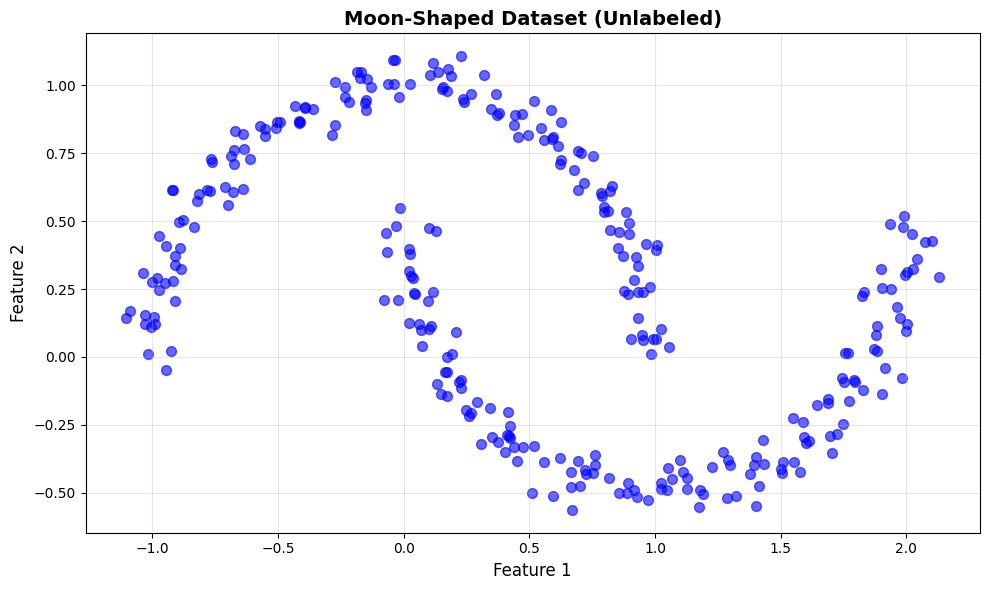

In [11]:
# Generate moon-shaped data
X_moons, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

print(f"Moon dataset shape: {X_moons.shape}")

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c='blue', alpha=0.6, s=50)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Moon-Shaped Dataset (Unlabeled)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Apply K-Means to Moon Data**

Apply K-Means clustering (k=2) to the moon-shaped data and visualize the results.

Running K-Means with k=2 for 10 iterations...

Iteration 1: Inertia = 135.88
Iteration 2: Inertia = 123.05
Iteration 3: Inertia = 121.19
Iteration 4: Inertia = 121.08
Iteration 5: Inertia = 121.01
Iteration 6: Inertia = 121.01
Iteration 7: Inertia = 121.01
Iteration 8: Inertia = 121.01
Iteration 9: Inertia = 121.01
Iteration 10: Inertia = 121.01


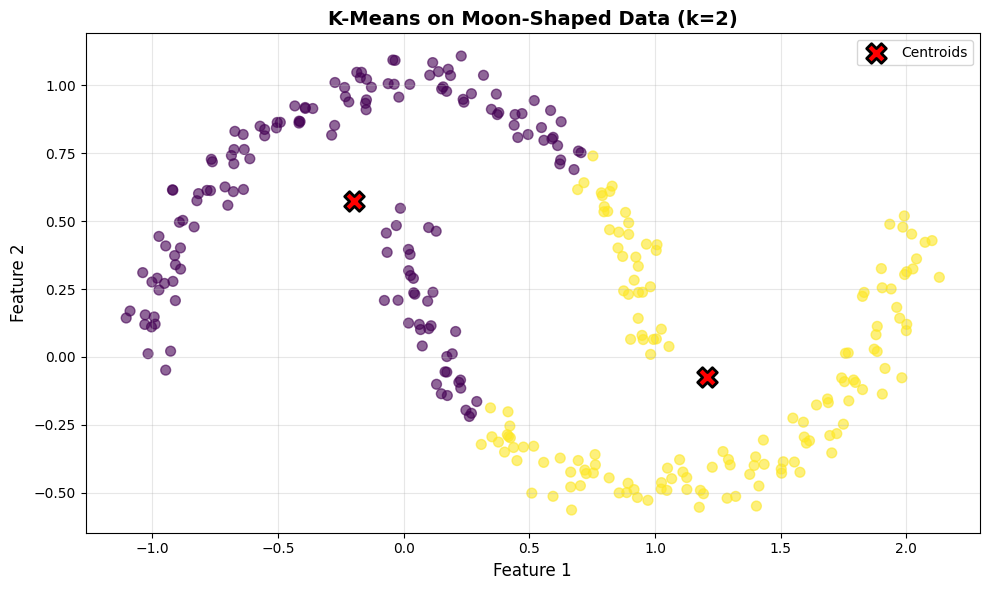

In [12]:
# Run K-Means on moon data
moon_centroids, moon_assignments, _ = kmeans(X_moons, k=2, n_iterations=10)

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=moon_assignments, cmap='viridis', alpha=0.6, s=50)
plt.scatter(moon_centroids[:, 0], moon_centroids[:, 1], 
            c='red', marker='X', s=200, edgecolors='black', linewidths=2,
            label='Centroids')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('K-Means on Moon-Shaped Data (k=2)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **TASK 9: QUESTION**

Does K-Means correctly identify the two moon shapes? Why or why not?

**YOUR ANSWER:**

(TODO: Put answer here)

## **TASK 10: Apply DBSCAN to Moon Data**

Now apply DBSCAN to the moon-shaped data. DBSCAN can detect arbitrarily shaped clusters based on density.

**Instructions:**
- Use `DBSCAN` from scikit-learn
- Start with `eps=0.2` and `min_samples=5`
- Visualize the results

Number of clusters found: 2
Number of noise points: 0


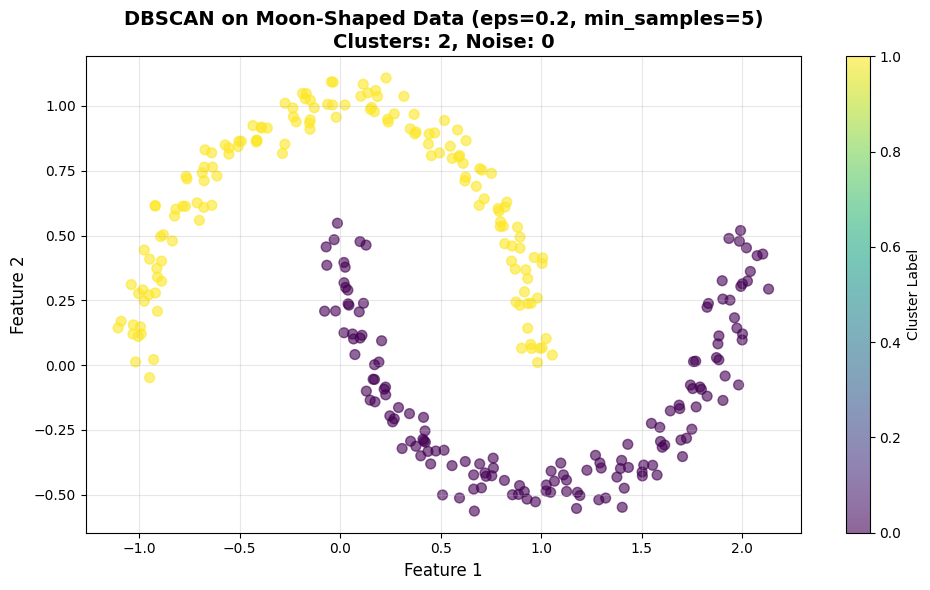

In [13]:
# Write your code here

# Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_moons)

# Count clusters and noise points
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.6, s=50)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title(f'DBSCAN on Moon-Shaped Data (eps=0.2, min_samples=5)\nClusters: {n_clusters}, Noise: {n_noise}', 
          fontsize=14, fontweight='bold')
plt.colorbar(label='Cluster Label')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **TASK 11: QUESTION**

How does DBSCAN's result compare to K-Means? Why is DBSCAN more successful on this dataset?

**YOUR ANSWER:**

(TODO: Put answer here)

## **TASK 12: Experiment with DBSCAN Parameters**

Experiment with different values of `eps` and `min_samples` to see how they affect the clustering results.

**Try these combinations:**
1. eps=0.1, min_samples=5
2. eps=0.5, min_samples=5
3. eps=0.2, min_samples=10

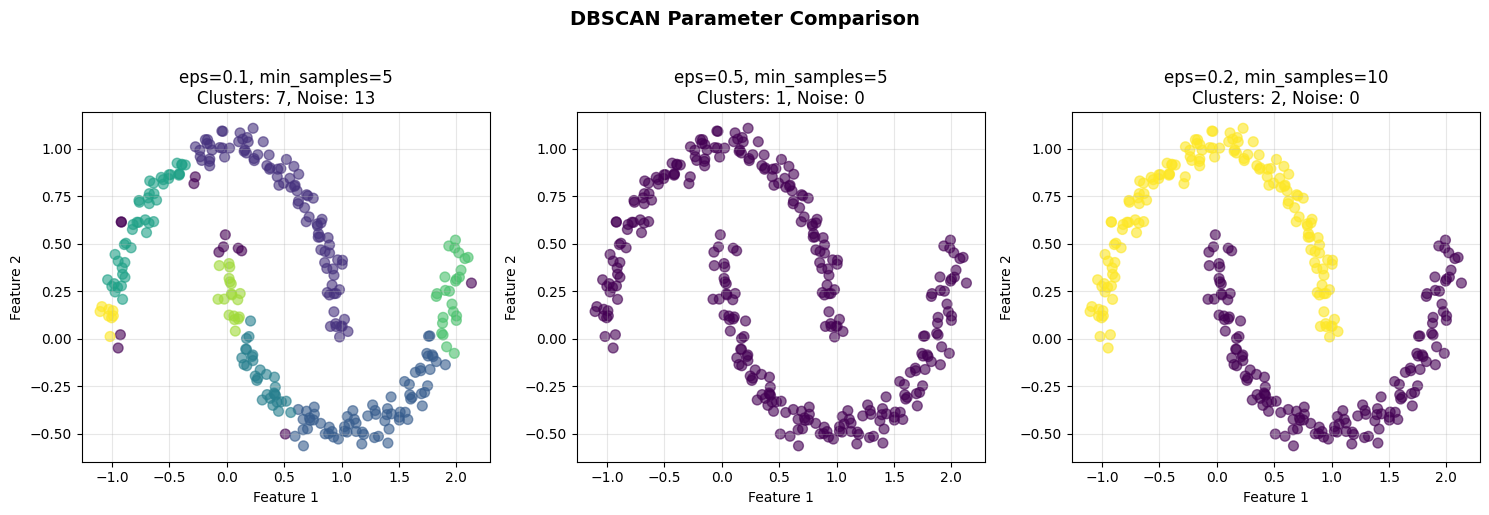

In [14]:
# Write your code here

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

params = [(0.1, 5), (0.5, 5), (0.2, 10)]  # List of (eps, min_samples) tuples to test

for ax, (eps, min_samples) in zip(axes, params):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_moons)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=labels, cmap='viridis', alpha=0.6, s=50)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'eps={eps}, min_samples={min_samples}\nClusters: {n_clusters}, Noise: {n_noise}')
    ax.grid(True, alpha=0.3)

plt.suptitle('DBSCAN Parameter Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **TASK 13: QUESTION**

How do the `eps` and `min_samples` parameters affect the clustering results? Describe the effect of each parameter.

**YOUR ANSWER:**

- **eps (epsilon)**: (TODO: Put answer here)

- **min_samples**: (TODO: Put answer here)


---
# **Part 3: Anomaly Detection with Clustering**
---

## **Create Dataset with Anomalies**

Create a dataset that contains normal data points (in clusters) and some anomalous points (outliers).

**Instructions:**
- Generate 300 normal points using `make_blobs` with 3 centers
- Add 15 random anomaly points scattered across the feature space
- Use a wider range for anomalies (e.g., [-10, 10] for both features)

Total points: 315
Normal points: 300
Anomaly points: 15


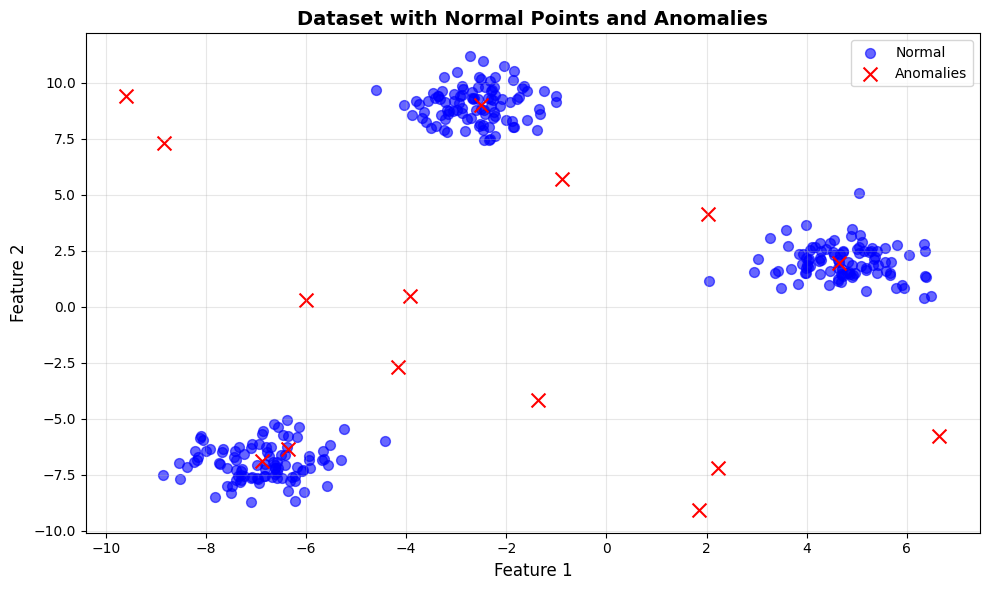

In [15]:
# Generate normal data
X_normal, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

# Generate anomalies (random points in a wider range)
np.random.seed(42)
n_anomalies = 15
X_anomalies = np.random.uniform(low=-10, high=10, size=(n_anomalies, 2))

# Combine normal data and anomalies
X_combined = np.vstack([X_normal, X_anomalies])

# Create labels (0 = normal, 1 = anomaly) for evaluation
true_anomaly_labels = np.array([0] * len(X_normal) + [1] * n_anomalies)

print(f"Total points: {len(X_combined)}")
print(f"Normal points: {len(X_normal)}")
print(f"Anomaly points: {n_anomalies}")

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_normal[:, 0], X_normal[:, 1], c='blue', alpha=0.6, s=50, label='Normal')
plt.scatter(X_anomalies[:, 0], X_anomalies[:, 1], c='red', marker='x', s=100, label='Anomalies')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Dataset with Normal Points and Anomalies', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **TASK 14: Anomaly Detection with DBSCAN**

Use DBSCAN for anomaly detection. DBSCAN naturally identifies outliers as noise points (labeled as -1).

**Instructions:**
- Apply DBSCAN to the combined dataset
- Identify points labeled as -1 (noise/anomalies)
- Visualize the results, highlighting detected anomalies

Number of clusters found: 8
Number of detected anomalies: 115


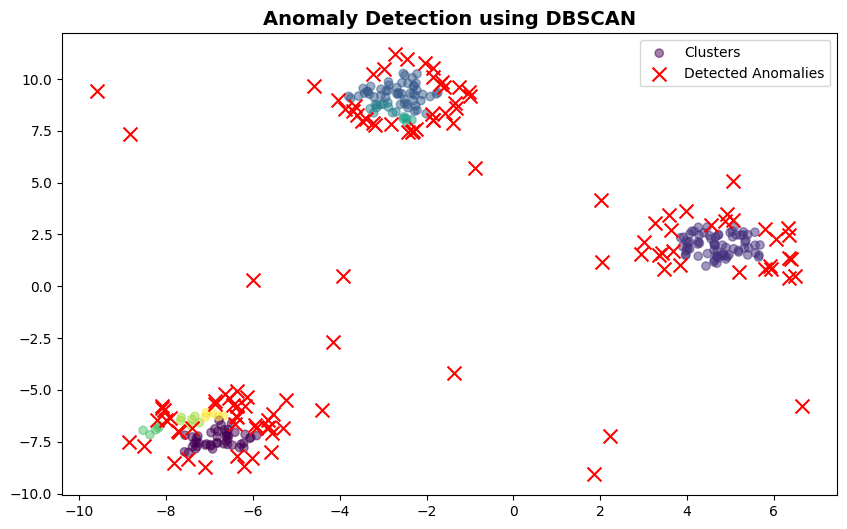

In [ ]:
# Write your code here

# Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_combined)

# Identify detected anomalies (label == -1)
detected_anomalies = dbscan_labels == -1

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_detected_anomalies = np.sum(detected_anomalies)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of detected anomalies: {n_detected_anomalies}")

# Visualize results
plt.figure(figsize=(10, 6))

plt.scatter(X_combined[dbscan_labels != -1, 0], X_combined[dbscan_labels != -1, 1], 
            c=dbscan_labels[dbscan_labels != -1], cmap='viridis', alpha=0.5, label='Clusters')

plt.scatter(X_combined[dbscan_labels == -1, 0], X_combined[dbscan_labels == -1, 1], 
            c='red', marker='x', s=100, label='Detected Anomalies')

plt.title('Anomaly Detection using DBSCAN', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

## **TASK 15: Evaluate Anomaly Detection Performance**

Compare the detected anomalies with the true anomaly labels to evaluate performance.

**Calculate:**
- True Positives (TP): Correctly detected anomalies
- False Positives (FP): Normal points incorrectly flagged as anomalies
- False Negatives (FN): Anomalies that were missed
- Precision: TP / (TP + FP)
- Recall: TP / (TP + FN)

In [19]:
# Write your code here

# Convert DBSCAN labels to binary anomaly predictions (1 if noise, 0 otherwise)
predicted_anomalies = (dbscan_labels == -1).astype(int)

# Calculate metrics
TP = np.sum((predicted_anomalies == 1) & (true_anomaly_labels == 1))
FP = np.sum((predicted_anomalies == 1) & (true_anomaly_labels == 0))
FN = np.sum((predicted_anomalies == 0) & (true_anomaly_labels == 1))
TN = np.sum((predicted_anomalies == 0) & (true_anomaly_labels == 0))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print("Anomaly Detection Performance:")
print("=" * 40)
print(f"\nTrue Positives (correctly detected anomalies): {TP}")
print(f"False Positives (normal flagged as anomaly): {FP}")
print(f"False Negatives (missed anomalies): {FN}")
print(f"True Negatives (correctly identified normal): {TN}")
print(f"\nPrecision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"\nTotal actual anomalies: {n_anomalies}")
print(f"Total detected anomalies: {n_detected_anomalies}")

Anomaly Detection Performance:

True Positives (correctly detected anomalies): 12
False Positives (normal flagged as anomaly): 103
False Negatives (missed anomalies): 3
True Negatives (correctly identified normal): 197

Precision: 10.43%
Recall: 80.00%

Total actual anomalies: 15
Total detected anomalies: 115


---
## **Summary and Key Takeaways**
---

### What we learned:

1. **K-Means Clustering**:
   - Partitions data into k clusters by minimizing within-cluster variance
   - Algorithm: Initialize centroids → Assign points → Update centroids → Repeat
   - Requires specifying k in advance
   - Works best with spherical, well-separated clusters
   - Assigns every point to a cluster (no outlier detection)

2. **DBSCAN Clustering**:
   - Density-based algorithm that groups points in high-density regions
   - Does not require specifying the number of clusters
   - Can find clusters of arbitrary shapes
   - Naturally identifies noise/outliers (points in low-density regions)
   - Key parameters: eps (neighborhood size) and min_samples (core point threshold)

3. **Anomaly Detection with Clustering**:
   - DBSCAN labels outliers as noise (-1)
   - Useful for identifying unusual data points automatically
   - Evaluation metrics: Precision (avoiding false positives) and Recall (catching all anomalies)

4. **Algorithm Selection**:
   - **Use K-Means when**: You know k, clusters are spherical, no outliers expected
   - **Use DBSCAN when**: Unknown number of clusters, irregular shapes, outlier detection needed

5. **Parameter Tuning**:
   - K-Means: Choose k using domain knowledge or elbow method
   - DBSCAN: eps controls cluster tightness, min_samples controls noise sensitivity

### Extensions to Explore:

- Implement the elbow method to find optimal k for K-Means
- Try K-Means++ initialization for better convergence
- Explore HDBSCAN (hierarchical DBSCAN) for automatic eps selection
- Apply clustering to real-world datasets (customer data, sensor readings)
- Combine clustering with dimensionality reduction (PCA, t-SNE) for visualization
- Experiment with other clustering algorithms (Hierarchical, Gaussian Mixture Models)
- Use silhouette score to evaluate clustering quality